# Data Preprocessing, Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    f1_score, auc, roc_auc_score, confusion_matrix, balanced_accuracy_score,
    roc_curve, accuracy_score
)

In [2]:
import os
# df = pd.read_csv(os.path.join('..', 'data', 'data_clean.csv'), index_col=0).reset_index()
df = pd.read_csv(os.path.join('..', 'data', 'data_clean.csv'), index_col=0)
df

,Residence_type,gender,hypertension,heart_disease,ever_married,work_type,smoking_status,age,avg_glucose_level,bmi,stroke
0,Urban,Male,0,1,Yes,Private,formerly smoked,67.0,228.69,36.6,1
2,Rural,Male,0,1,Yes,Private,never smoked,80.0,105.92,32.5,1
3,Urban,Female,0,0,Yes,Private,smokes,49.0,171.23,34.4,1
4,Rural,Female,1,0,Yes,Self-employed,never smoked,79.0,174.12,24.0,1
5,Urban,Male,0,0,Yes,Private,formerly smoked,81.0,186.21,29.0,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,Rural,Female,0,0,No,children,Unknown,13.0,103.08,18.6,0
5106,Urban,Female,0,0,Yes,Self-employed,never smoked,81.0,125.20,40.0,0
5107,Rural,Female,0,0,Yes,Self-employed,never smoked,35.0,82.99,30.6,0
5108,Rural,Male,0,0,Yes,Private,formerly smoked,51.0,166.29,25.6,0


### Feature Engineering and Transformations

In [3]:
df['is_urban'] = (df['Residence_type'] == 'Urban').astype(np.int8)
df['is_male'] = (df['gender'] == 'Male').astype(np.int8)
df['ever_married'] = (df['ever_married'] == 'Yes').astype(np.int8)
df.head()

,Residence_type,gender,hypertension,heart_disease,ever_married,work_type,smoking_status,age,avg_glucose_level,bmi,stroke,is_urban,is_male
0,Urban,Male,0,1,1,Private,formerly smoked,67.0,228.69,36.6,1,1,1
2,Rural,Male,0,1,1,Private,never smoked,80.0,105.92,32.5,1,0,1
3,Urban,Female,0,0,1,Private,smokes,49.0,171.23,34.4,1,1,0
4,Rural,Female,1,0,1,Self-employed,never smoked,79.0,174.12,24.0,1,0,0
5,Urban,Male,0,0,1,Private,formerly smoked,81.0,186.21,29.0,1,1,1


In [4]:
# df = df[[
#     'age', 'is_male', 'is_urban', 'ever_married', 'work_type', 'smoking_status',
#     'bmi', 'hypertension', 'heart_disease', 'avg_glucose_level', 'stroke'
# ]]
# df.head()

In [5]:
df.dtypes

Residence_type        object
gender                object
hypertension           int64
heart_disease          int64
ever_married            int8
work_type             object
smoking_status        object
age                  float64
avg_glucose_level    float64
bmi                  float64
stroke                 int64
is_urban                int8
is_male                 int8
dtype: object

Things like age groups and bmi categories can help the model pick up on non-linear patterns that raw continuous values sometimes miss.

In [6]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 35, 50, 65, np.inf],
    labels=['<18', '18-35', '36-50', '51-65', '65+']
)

df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df['avg_glucose_category'] = pd.cut(
    df['avg_glucose_level'],
    bins=[0, 70, 100, 250, np.inf],
    labels=['Low', 'Normal', 'High', 'VeryHigh']
)

In [7]:
df['ever_smoked'] = (df['smoking_status'].apply(
    lambda x: 1 if x in ['formerly smoked', 'smokes'] else 0
)).astype(np.int8)

df['age_bmi_interaction'] = df['age'] * df['bmi']

df['health_risk_score'] = (
    df['hypertension'] + df['heart_disease'] + df['ever_smoked'] + df['age'] / 100
)

df['work_residence_interaction'] = df['work_type'] + "_" + df['Residence_type']

df['marital_age_interaction'] = df['ever_married'] * df['age']

df.sample(3)

,Residence_type,gender,hypertension,heart_disease,ever_married,work_type,smoking_status,age,avg_glucose_level,bmi,...,is_urban,is_male,age_group,bmi_category,avg_glucose_category,ever_smoked,age_bmi_interaction,health_risk_score,work_residence_interaction,marital_age_interaction
4732,Urban,Female,0,0,1,Private,never smoked,45.0,108.03,37.3,...,1,0,36-50,Obese,High,0,1678.5,0.45,Private_Urban,45.0
2161,Urban,Female,1,0,1,Govt_job,never smoked,55.0,186.40,28.0,...,1,0,51-65,Overweight,High,0,1540.0,1.55,Govt_job_Urban,55.0
4662,Rural,Male,0,0,0,Private,never smoked,14.0,84.41,33.9,...,0,1,<18,Obese,Normal,0,474.6,0.14,Private_Rural,0.0


In [8]:
df.dtypes

Residence_type                  object
gender                          object
hypertension                     int64
heart_disease                    int64
ever_married                      int8
work_type                       object
smoking_status                  object
age                            float64
avg_glucose_level              float64
bmi                            float64
stroke                           int64
is_urban                          int8
is_male                           int8
age_group                     category
bmi_category                  category
avg_glucose_category          category
ever_smoked                       int8
age_bmi_interaction            float64
health_risk_score              float64
work_residence_interaction      object
marital_age_interaction        float64
dtype: object

In [9]:
df.drop(['Residence_type', 'gender'], axis=1, inplace=True)
df

,hypertension,heart_disease,ever_married,work_type,smoking_status,age,avg_glucose_level,bmi,stroke,is_urban,is_male,age_group,bmi_category,avg_glucose_category,ever_smoked,age_bmi_interaction,health_risk_score,work_residence_interaction,marital_age_interaction
0,0,1,1,Private,formerly smoked,67.0,228.69,36.6,1,1,1,65+,Obese,High,1,2452.2,2.67,Private_Urban,67.0
2,0,1,1,Private,never smoked,80.0,105.92,32.5,1,0,1,65+,Obese,High,0,2600.0,1.80,Private_Rural,80.0
3,0,0,1,Private,smokes,49.0,171.23,34.4,1,1,0,36-50,Obese,High,1,1685.6,1.49,Private_Urban,49.0
4,1,0,1,Self-employed,never smoked,79.0,174.12,24.0,1,0,0,65+,Normal,High,0,1896.0,1.79,Self-employed_Rural,79.0
5,0,0,1,Private,formerly smoked,81.0,186.21,29.0,1,1,1,65+,Overweight,High,1,2349.0,1.81,Private_Urban,81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,0,0,0,children,Unknown,13.0,103.08,18.6,0,0,0,<18,Normal,High,0,241.8,0.13,children_Rural,0.0
5106,0,0,1,Self-employed,never smoked,81.0,125.20,40.0,0,1,0,65+,Obese,High,0,3240.0,0.81,Self-employed_Urban,81.0
5107,0,0,1,Self-employed,never smoked,35.0,82.99,30.6,0,0,0,18-35,Obese,Normal,0,1071.0,0.35,Self-employed_Rural,35.0
5108,0,0,1,Private,formerly smoked,51.0,166.29,25.6,0,0,1,51-65,Overweight,High,1,1305.6,1.51,Private_Rural,51.0


### Feature Encoding, Scaling

In [10]:
cat_encode_cols = [
    'hypertension', 'heart_disease', 'work_type', 'smoking_status', 'is_urban',
    'is_male', 'age_group', 'bmi_category', 'avg_glucose_category', 'ever_smoked',
    'ever_married', 'work_residence_interaction',
]

df = pd.get_dummies(df, columns=cat_encode_cols, drop_first=True)

for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(np.int8)

In [11]:
df.head(3)

,age,avg_glucose_level,bmi,stroke,age_bmi_interaction,health_risk_score,marital_age_interaction,hypertension_1,heart_disease_1,work_type_Never_worked,...,ever_married_1,work_residence_interaction_Govt_job_Urban,work_residence_interaction_Never_worked_Rural,work_residence_interaction_Never_worked_Urban,work_residence_interaction_Private_Rural,work_residence_interaction_Private_Urban,work_residence_interaction_Self-employed_Rural,work_residence_interaction_Self-employed_Urban,work_residence_interaction_children_Rural,work_residence_interaction_children_Urban
0,67.0,228.69,36.6,1,2452.2,2.67,67.0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
2,80.0,105.92,32.5,1,2600.0,1.80,80.0,0,1,0,...,1,0,0,0,1,0,0,0,0,0
3,49.0,171.23,34.4,1,1685.6,1.49,49.0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


In [12]:
df.dtypes

age                                               float64
avg_glucose_level                                 float64
bmi                                               float64
stroke                                              int64
age_bmi_interaction                               float64
health_risk_score                                 float64
marital_age_interaction                           float64
hypertension_1                                       int8
heart_disease_1                                      int8
work_type_Never_worked                               int8
work_type_Private                                    int8
work_type_Self-employed                              int8
work_type_children                                   int8
smoking_status_formerly smoked                       int8
smoking_status_never smoked                          int8
smoking_status_smokes                                int8
is_urban_1                                           int8
is_male_1     

In [13]:
y = df["stroke"]
X = df.drop("stroke", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_features = [
    'age', 'avg_glucose_level', 'bmi', 'age_bmi_interaction',
    'health_risk_score', 'marital_age_interaction'
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head()

,age,avg_glucose_level,bmi,age_bmi_interaction,health_risk_score,marital_age_interaction,hypertension_1,heart_disease_1,work_type_Never_worked,work_type_Private,...,ever_married_1,work_residence_interaction_Govt_job_Urban,work_residence_interaction_Never_worked_Rural,work_residence_interaction_Never_worked_Urban,work_residence_interaction_Private_Rural,work_residence_interaction_Private_Urban,work_residence_interaction_Self-employed_Rural,work_residence_interaction_Self-employed_Urban,work_residence_interaction_children_Rural,work_residence_interaction_children_Urban
4649,0.096680,0.298815,0.155914,0.032788,0.020737,0.00000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1172,0.487305,0.293125,0.548387,0.315078,0.366359,0.00000,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
49,0.475098,0.013967,0.776882,0.392327,0.625576,0.47561,1,0,0,1,...,1,0,0,0,1,0,0,0,0,0
2346,0.169922,0.438535,0.333333,0.081326,0.036447,0.00000,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1134,0.018066,0.181622,0.263441,0.007763,0.003875,0.00000,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [15]:
X_train_scaled.dtypes

age                                               float64
avg_glucose_level                                 float64
bmi                                               float64
age_bmi_interaction                               float64
health_risk_score                                 float64
marital_age_interaction                           float64
hypertension_1                                       int8
heart_disease_1                                      int8
work_type_Never_worked                               int8
work_type_Private                                    int8
work_type_Self-employed                              int8
work_type_children                                   int8
smoking_status_formerly smoked                       int8
smoking_status_never smoked                          int8
smoking_status_smokes                                int8
is_urban_1                                           int8
is_male_1                                            int8
age_group_18-3

In [16]:
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    scoring='recall',
    param_grid=rf_params,
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='recall')

In [17]:
y_pred = rf_grid.predict(X_test_scaled)

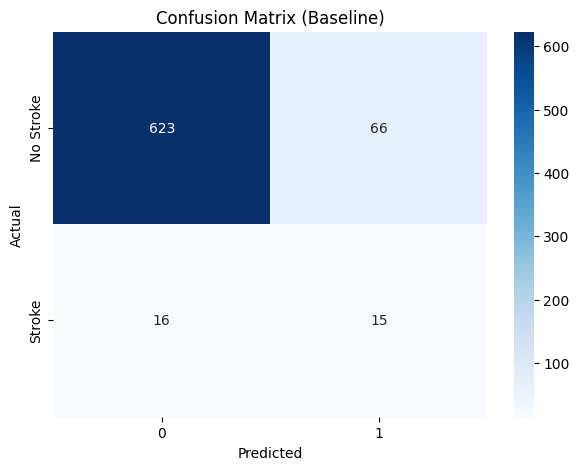

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", yticklabels=["No Stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Baseline)")
plt.show()

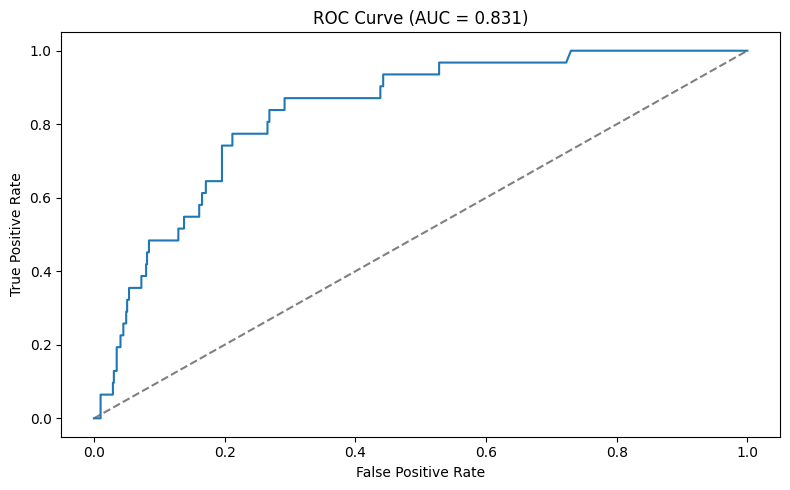

In [19]:
probs = rf_grid.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(8, 5))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {round(auc, 3)})')
plt.tight_layout()
plt.show()

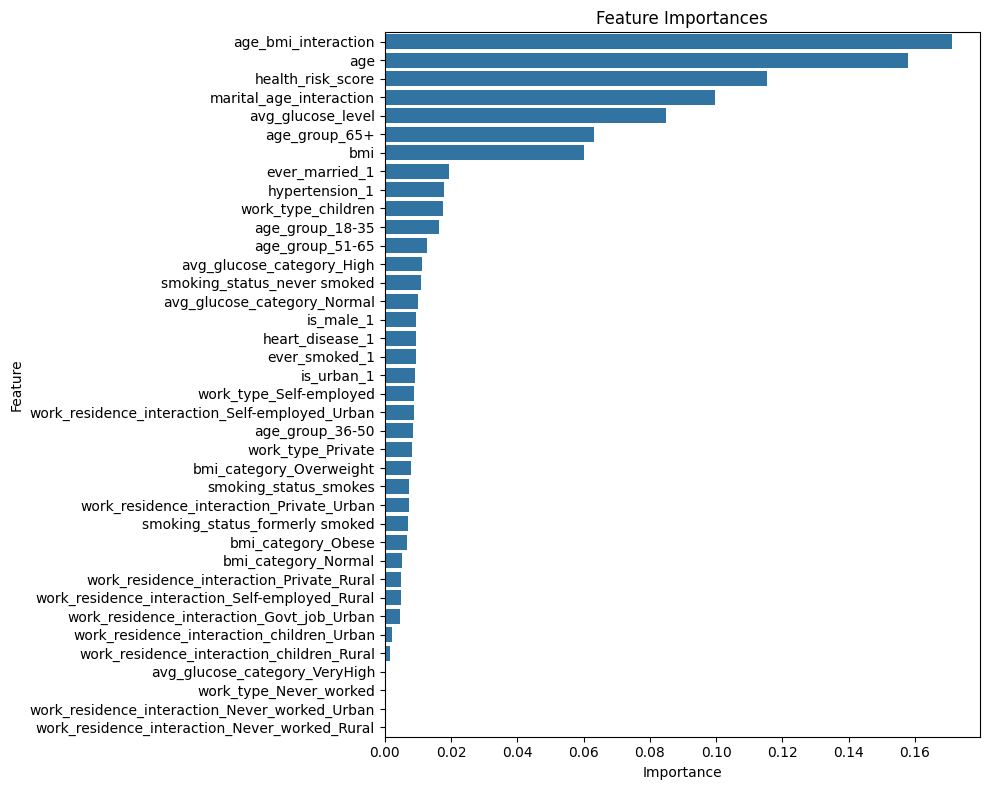

In [20]:
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_grid.best_estimator_.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [21]:
lr_params = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42), param_grid=lr_params, cv=5
)

lr_grid.fit(X_train_scaled, y_train)
lr_grid.best_score_

c:\Users\Mike\Workspace\___.Priority.___\GitHub\stroke-prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Mike\Workspace\___.Priority.___\GitHub\stroke-prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Mike\Workspace\___.Priority.___\GitHub\stroke-prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Mike\Workspace\___.Priority.___\GitHub\stroke-prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Mike\Workspace\___.Priority.___\GitHub\stroke-prediction\.venv\Lib\site-packages\sklearn\model_selection\_validatio

np.float64(0.9570867917719236)

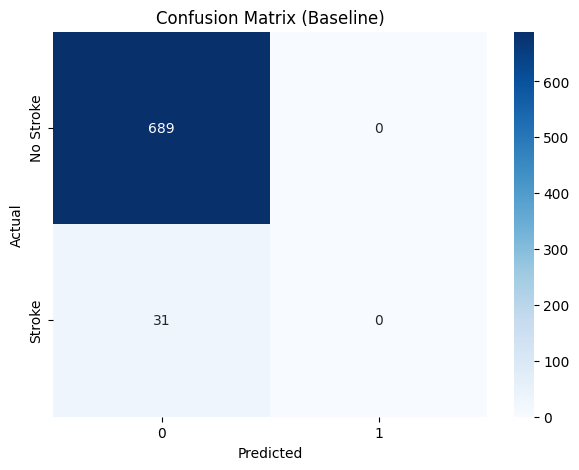

In [22]:
y_pred = lr_grid.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", yticklabels=["No Stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Baseline)")
plt.show()

In [23]:
from imblearn.over_sampling import SMOTE

print(X_train_scaled.shape)
print(y_train.value_counts(normalize=True))

over = SMOTE(sampling_strategy=0.3, random_state=42)
X_train_scaled_smote, y_train_smote = over.fit_resample(X_train_scaled, y_train)

print(X_train_scaled_smote.shape)
print(y_train_smote.value_counts(normalize=True))

(4078, 38)
stroke
0    0.956842
1    0.043158
Name: proportion, dtype: float64
(5072, 38)
stroke
0    0.769322
1    0.230678
Name: proportion, dtype: float64


In [24]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm, columns=['Predicted: 0', 'Predicted: 1'], index=['Actual: 0', 'Actual: 1']
    )
    plt.figure(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def plot_roc(clf, X_test, y_test):
    probs = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    plt.figure(figsize=(8, 5))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (AUC = {round(auc, 3)})')
    plt.tight_layout()
    plt.show()
    return auc

In [25]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    scoring='recall',
    param_grid=rf_params,
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_scaled_smote, y_train_smote)
rf_grid.best_score_

np.float64(0.9205128205128206)

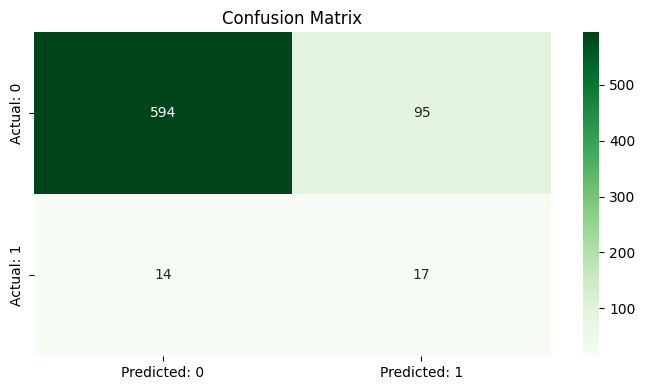

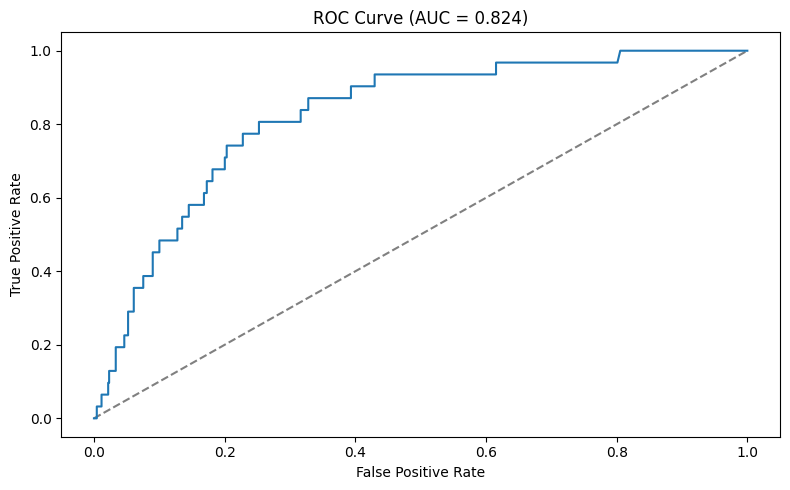

np.float64(0.8239852052998736)

In [26]:
y_pred = rf_grid.predict(X_test_scaled)
plot_confusion_matrix(y_test, y_pred)
plot_roc(rf_grid, X_test_scaled, y_test)

In [27]:
import warnings
warnings.filterwarnings('ignore')

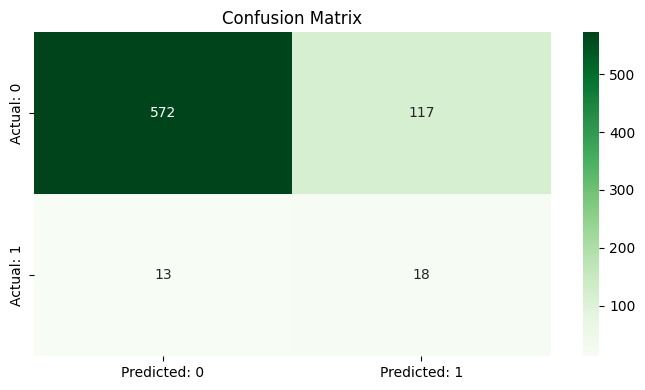

In [28]:
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42), param_grid=lr_params, cv=5,
    scoring='recall'
)

lr_grid.fit(X_train_scaled_smote, y_train_smote)
plot_confusion_matrix(y_test, lr_grid.predict(X_test_scaled))

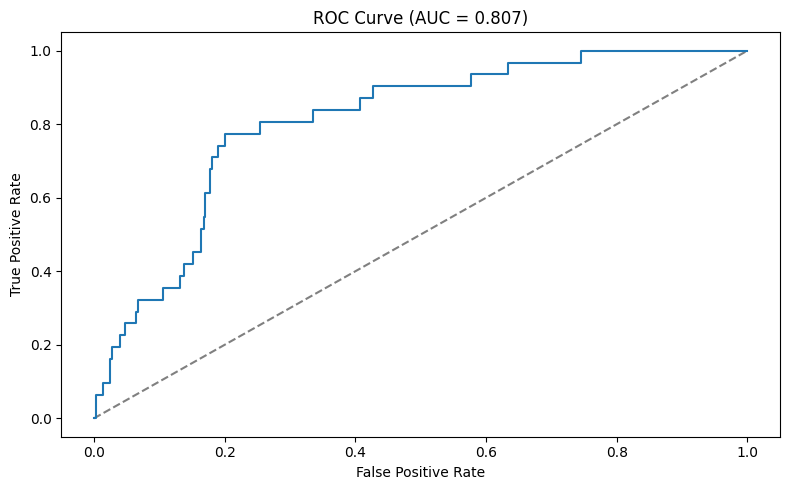

np.float64(0.806966618287373)

In [29]:
plot_roc(lr_grid, X_test_scaled, y_test)

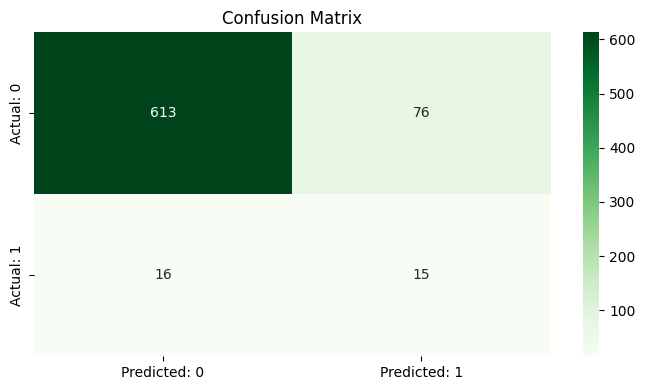

0.1
0.4838709677419355


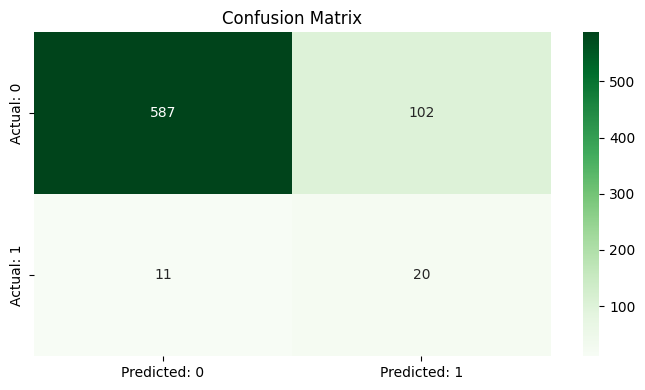

0.2
0.6451612903225806


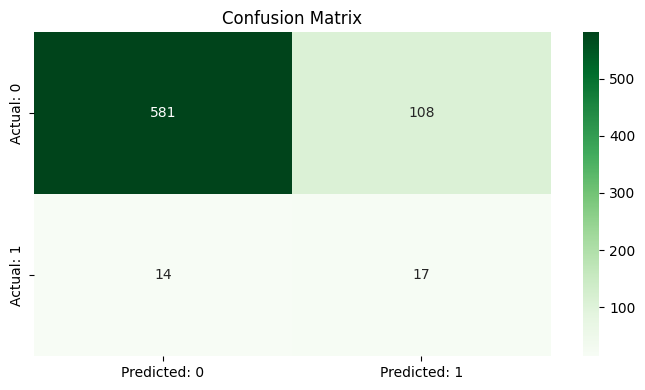

0.30000000000000004
0.5483870967741935


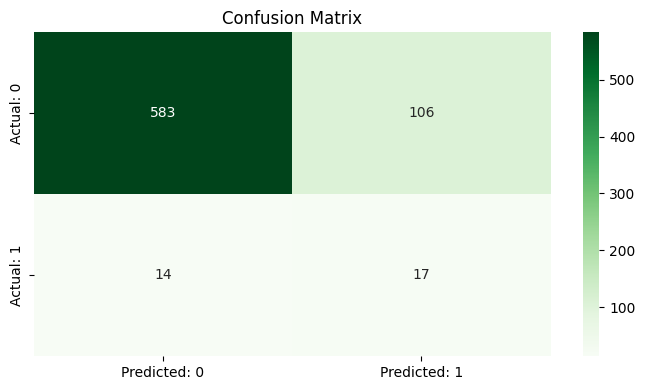

0.4
0.5483870967741935


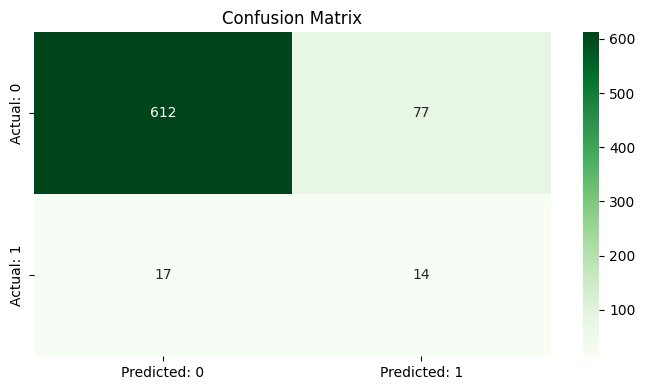

0.5
0.45161290322580644


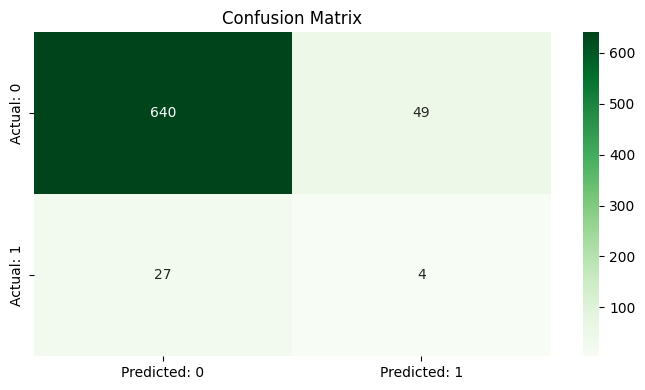

0.6
0.12903225806451613


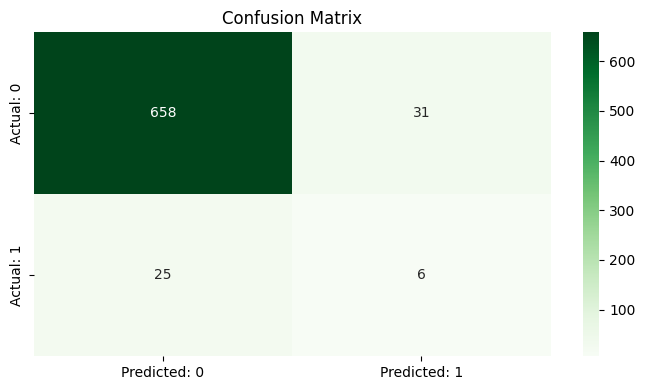

0.7000000000000001
0.1935483870967742


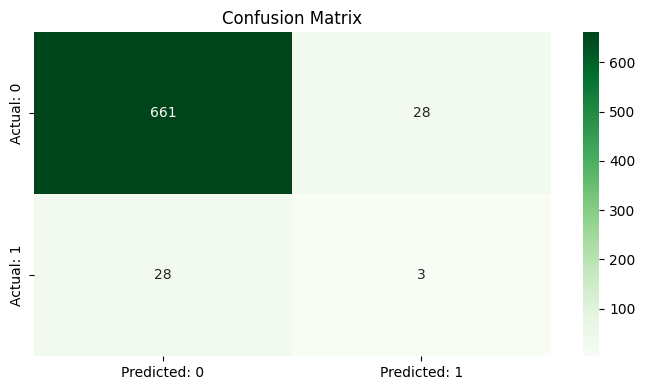

0.8
0.0967741935483871


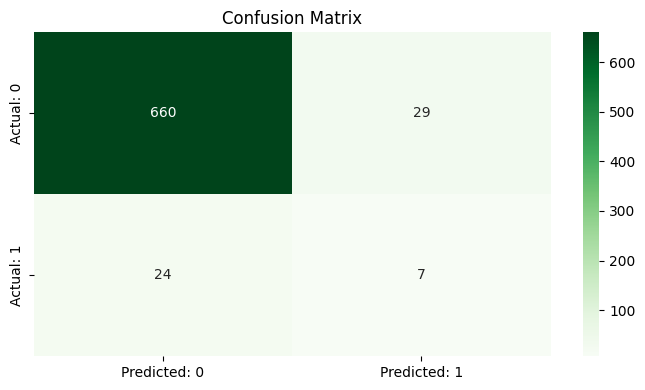

0.9
0.22580645161290322


In [30]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score

param_space = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

for i in np.arange(0.1, 1, 0.1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y
    )
    scaler = MinMaxScaler()
    num_features = [
        'age', 'avg_glucose_level', 'bmi', 'age_bmi_interaction',
        'health_risk_score', 'marital_age_interaction'
    ]
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
    X_test_scaled[num_features] = scaler.transform(X_test[num_features])

    over = SMOTE(sampling_strategy=i, random_state=42)
    X_train_scaled_smote, y_train_smote = over.fit_resample(X_train_scaled, y_train)
    rf_grid = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
        scoring='recall',
        param_distributions=param_space,
        n_iter=30,
        cv=5,
        n_jobs=-1
    )
    rf_grid.fit(X_train_scaled_smote, y_train_smote)
    y_pred = rf_grid.predict(X_test_scaled)
    plot_confusion_matrix(y_test, y_pred)
    print(i, recall_score(y_test, y_pred),sep='\n')

I used fresh train test splits in each iteration of the loop with oversampling to add some rigor to this practice (otherwise it would be simply overfitting the pipeline and models to the data)... This suggests 0.1 maybe the best ratio to set for oversampling with SMOTE, though this may also be due to chance. However since there is a gradient, as the oversampling factor increases the recall score decreases, and also because logically adding more data points makes information carried by each data point to be diluted, I will be proceeding with `0.1` oversampling factor.

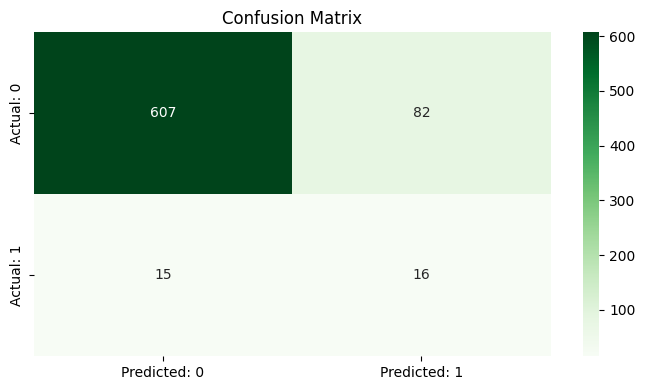

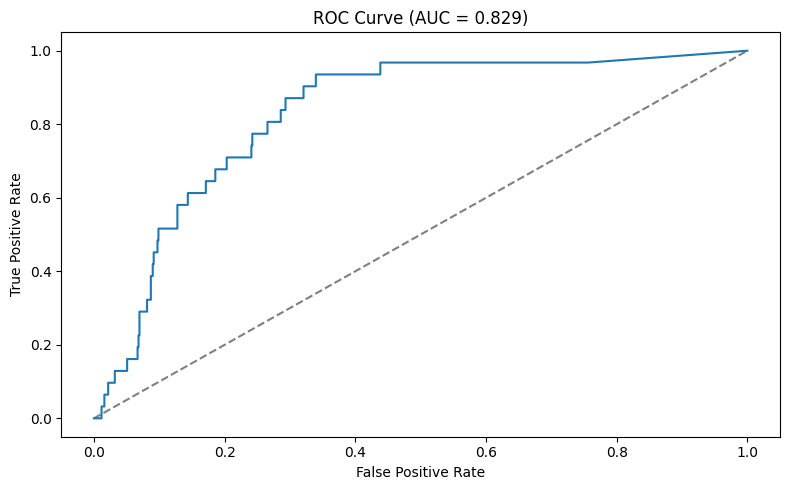

np.float64(0.8289245751205582)

In [31]:
OVERSAMPLING_FACTOR = 0.1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
scaler = MinMaxScaler()
num_features = [
    'age', 'avg_glucose_level', 'bmi', 'age_bmi_interaction',
    'health_risk_score', 'marital_age_interaction'
]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

over = SMOTE(sampling_strategy=OVERSAMPLING_FACTOR, random_state=42)
X_train_scaled_smote, y_train_smote = over.fit_resample(X_train_scaled, y_train)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    scoring='recall',
    param_grid=rf_params,
    cv=5,
    n_jobs=-1
)
rf_grid.fit(X_train_scaled_smote, y_train_smote)
y_pred = rf_grid.predict(X_test_scaled)
plot_confusion_matrix(y_test, y_pred)
plot_roc(rf_grid, X_test_scaled, y_test)

In [32]:
print(f"Random Forest Final Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Random Forest Final F1: {f1_score(y_test, y_pred, labels=[1])}")
print(f"Random Forest Final Recall: {recall_score(y_test, y_pred, labels=[1])}")

Random Forest Final Accuracy: 0.8652777777777778
Random Forest Final F1: 0.24806201550387597
Random Forest Final Recall: 0.5161290322580645


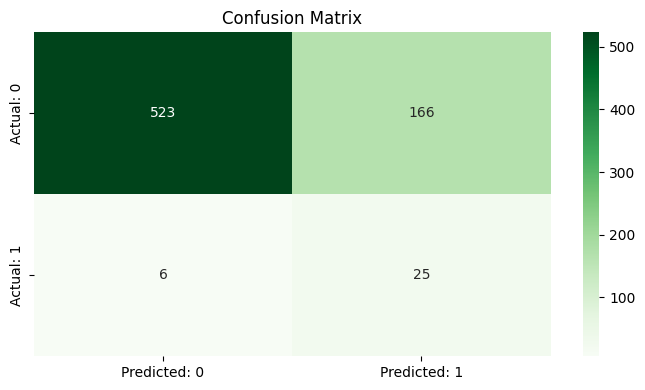

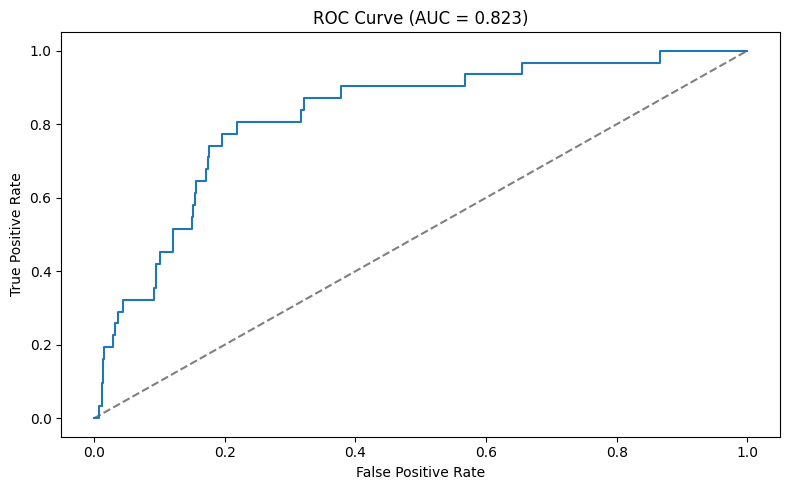

np.float64(0.8227913291820778)

In [33]:
lr_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    scoring='recall',
    param_grid=lr_params,
    cv=5,
    n_jobs=-1
)
lr_grid.fit(X_train_scaled_smote, y_train_smote)
y_pred = lr_grid.predict(X_test_scaled)
plot_confusion_matrix(y_test, y_pred)
plot_roc(lr_grid, X_test_scaled, y_test)

As it is shown oversampling with SMOTE using `OVERSAMPLING_FACTOR = 0.1` can increase recall, but obviously this comes at the cost of percision.

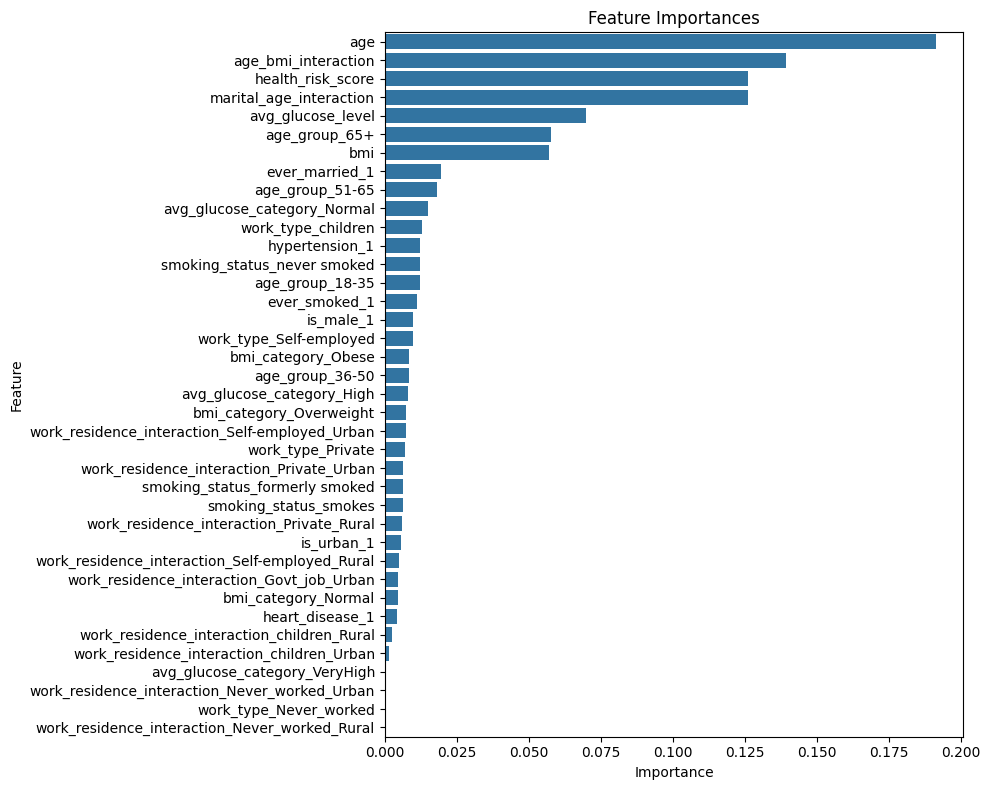

In [34]:
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_grid.best_estimator_.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

Since we have included numeric features (age, bmi, average glucose) as categorical features as well, it would be useful to see if removing these to eliminate their effect in our predictive models would make any difference. Let's also remove `age_bmi_interaction` as well. Although inclusion of these doesn't lead to colinearity issues (because Random Forest and LogisticRegression with L1/L2 regularization is immune to this effect to a great extent), but it may be useful to test those options as well.

In [35]:
X_train_scaled_smote.columns

Index(['age', 'avg_glucose_level', 'bmi', 'age_bmi_interaction',
       'health_risk_score', 'marital_age_interaction', 'hypertension_1',
       'heart_disease_1', 'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes', 'is_urban_1', 'is_male_1', 'age_group_18-35',
       'age_group_36-50', 'age_group_51-65', 'age_group_65+',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese',
       'avg_glucose_category_Normal', 'avg_glucose_category_High',
       'avg_glucose_category_VeryHigh', 'ever_smoked_1', 'ever_married_1',
       'work_residence_interaction_Govt_job_Urban',
       'work_residence_interaction_Never_worked_Rural',
       'work_residence_interaction_Never_worked_Urban',
       'work_residence_interaction_Private_Rural',
       'work_residence_interaction_Private_Urban',
       'work_residence_interaction

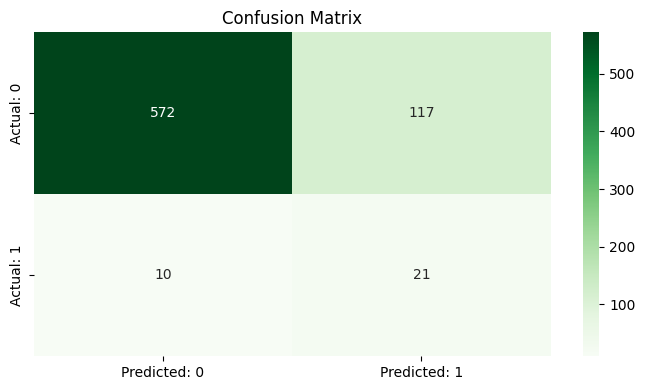

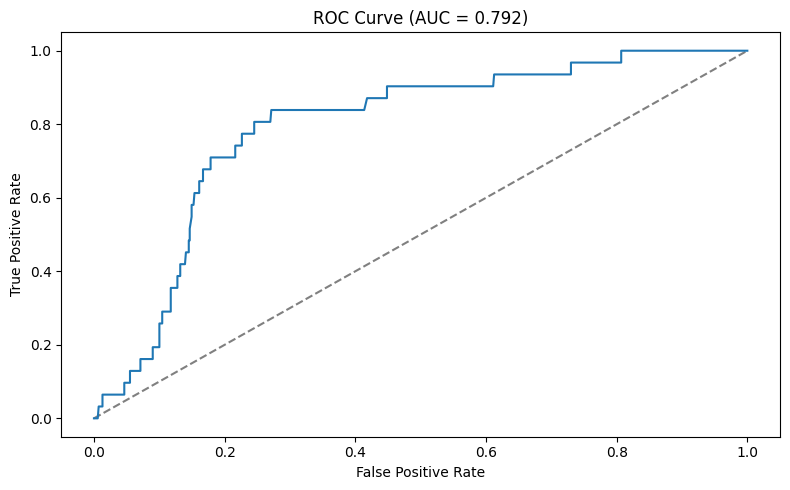

np.float64(0.7921719181609627)

In [36]:
# removed_features = ['age', 'bmi', 'avg_glucose_level',]
# removed_features = ['age', 'bmi', 'avg_glucose_level', 'age_bmi_interaction']
removed_features = ['age', 'bmi', 'avg_glucose_level', 'age_bmi_interaction',
                    'marital_age_interaction', 'health_risk_score']
X_train_scaled_smote_modified = X_train_scaled_smote.drop(removed_features, axis=1)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    scoring='recall',
    param_grid=rf_params,
    cv=5,
    n_jobs=-1
)
X_test_scaled_modified = X_test_scaled.drop(removed_features, axis=1)
rf_grid.fit(X_train_scaled_smote_modified, y_train_smote)
y_pred = rf_grid.predict(X_test_scaled_modified)
plot_confusion_matrix(y_test, y_pred)
plot_roc(rf_grid, X_test_scaled_modified, y_test)

In [37]:
print(f"Random Forest Final Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Random Forest Final F1: {f1_score(y_test, y_pred, labels=[1])}")
print(f"Random Forest Final Recall: {recall_score(y_test, y_pred, labels=[1])}")

Random Forest Final Accuracy: 0.8236111111111111
Random Forest Final F1: 0.2485207100591716
Random Forest Final Recall: 0.6774193548387096


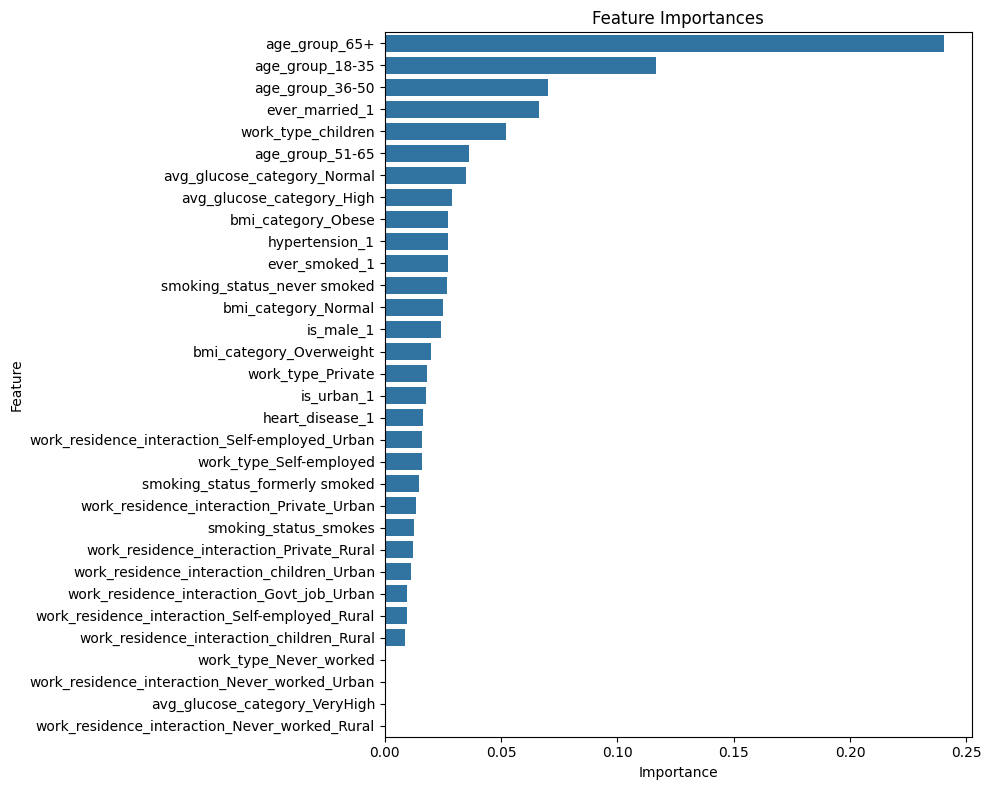

In [38]:
feat_imp = pd.DataFrame({
    "Feature": X_train_scaled_smote_modified.columns,
    "Importance": rf_grid.best_estimator_.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [39]:
X_train_scaled_smote.columns

Index(['age', 'avg_glucose_level', 'bmi', 'age_bmi_interaction',
       'health_risk_score', 'marital_age_interaction', 'hypertension_1',
       'heart_disease_1', 'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes', 'is_urban_1', 'is_male_1', 'age_group_18-35',
       'age_group_36-50', 'age_group_51-65', 'age_group_65+',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese',
       'avg_glucose_category_Normal', 'avg_glucose_category_High',
       'avg_glucose_category_VeryHigh', 'ever_smoked_1', 'ever_married_1',
       'work_residence_interaction_Govt_job_Urban',
       'work_residence_interaction_Never_worked_Rural',
       'work_residence_interaction_Never_worked_Urban',
       'work_residence_interaction_Private_Rural',
       'work_residence_interaction_Private_Urban',
       'work_residence_interaction

In [40]:
all_cols = X_train_scaled_smote.columns
removed_features = [
    [c for c in all_cols if c.startswith('age_group')],
    [c for c in all_cols if c.startswith('bmi_category')],
    [c for c in all_cols if c.startswith('avg_glucose_category')],
]
removed_features

[['age_group_18-35', 'age_group_36-50', 'age_group_51-65', 'age_group_65+'],
 ['bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
 ['avg_glucose_category_Normal',
  'avg_glucose_category_High',
  'avg_glucose_category_VeryHigh']]

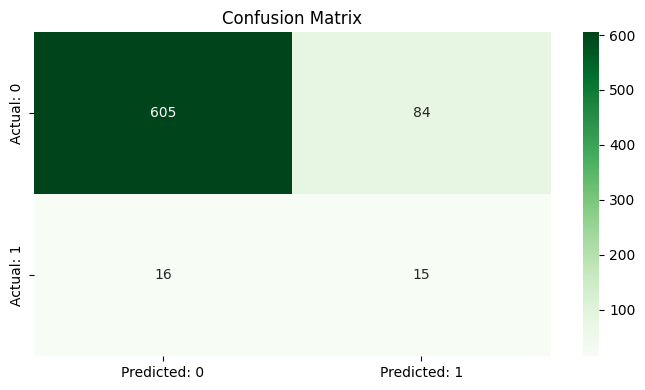

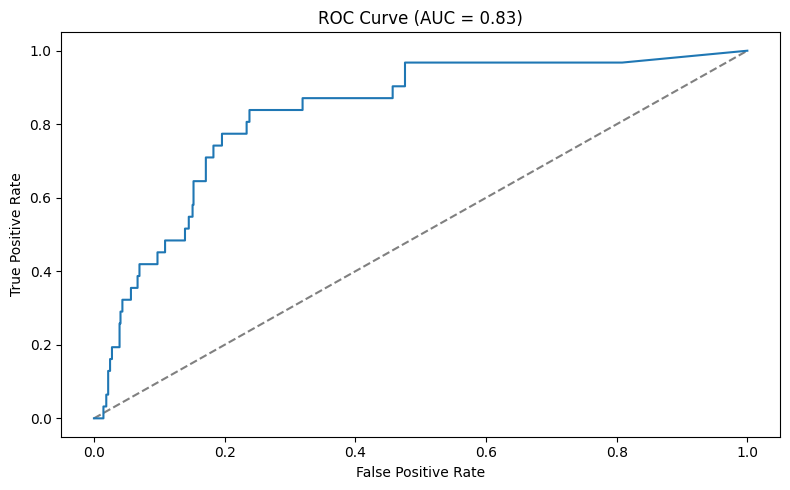

np.float64(0.8304227726017135)

In [41]:
removed_features = sum(removed_features, [])
X_train_scaled_smote_modified = X_train_scaled_smote.drop(removed_features, axis=1)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    scoring='recall',
    param_grid=rf_params,
    cv=5,
    n_jobs=-1
)
X_test_scaled_modified = X_test_scaled.drop(removed_features, axis=1)
rf_grid.fit(X_train_scaled_smote_modified, y_train_smote)
y_pred = rf_grid.predict(X_test_scaled_modified)
plot_confusion_matrix(y_test, y_pred)
plot_roc(rf_grid, X_test_scaled_modified, y_test)

In [ ]:
print(f"Random Forest Final Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Random Forest Final F1: {f1_score(y_test, y_pred, labels=[1])}")
print(f"Random Forest Final Recall: {recall_score(y_test, y_pred, labels=[1])}")

Random Forest Final Accuracy: 0.8611111111111112
Random Forest Final F1: 0.23076923076923078
Random Forest Final Recall: 0.4838709677419355


These observations suggest transforming numeric features (age, bmi, glucose to categorical features has paid off), and exclusion of those numeric features while decreasing overall accuracy, marginally, increases positive case recall, which is important for us. Also the appropriate approach for dealing with target class imbalance (SMOTE with `factor=0.1`, enforcing `class_weight='balanced'` in model initialization, and using 'recall' as optimizing scorer for Cross Validation hyperparameter tuning) was significantly helpful...